In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt

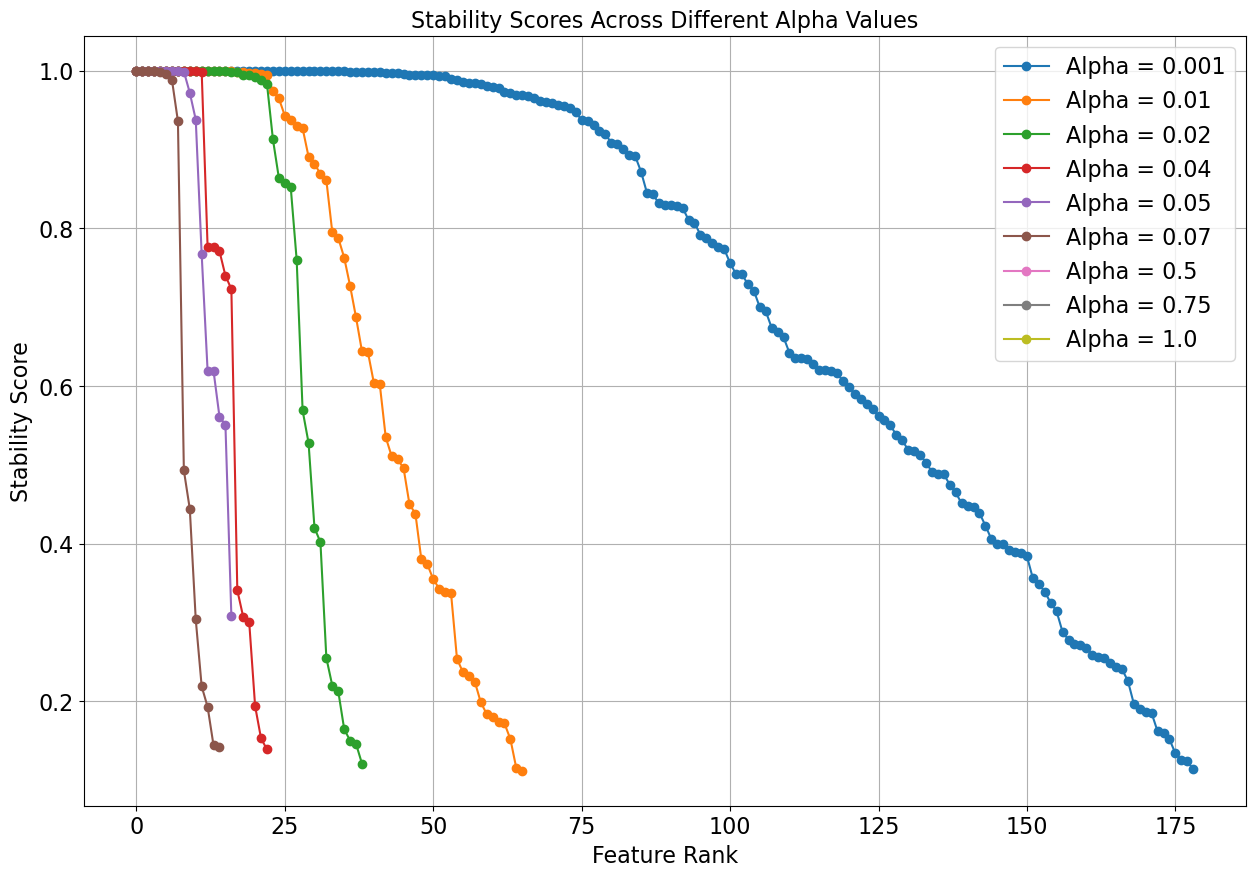

In [2]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt

# Load data
df=pd.read_csv('dreamt_preprocessed.csv')
### Removing the skewnes and kurtosis
# Identify columns to drop if they exist
columns_to_drop = [col for col in df.columns if 'skewness' in col.lower() or 'kurtosis' in col.lower()]
# Drop only those columns that actually exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

### Reomove 2 subject has data isuues
df_rms = df[~df['subject'].isin(['S062', 'S097'])]
df = df_rms[df_rms['label'].isin([0,1,2])]
# df

### Can be tested by using a few subject "#[:10]" need to remove :10 means 10 subject
sample=df.subject.unique()#[:10]
# # Sample the data (if needed)
df_sample = df[df.subject.isin(sample)]
# print(df_sample.shape)
# Split features and labels
X = df_sample.drop(columns=['subject','epoch','label'])
y = df_sample['label']

# # Split features and labels
# X = df.drop(columns=['subject','epoch','label','map_label'])
# y = df['map_label']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Number of bootstrap samples
n_bootstrap = 1000
n_features = X.shape[1]

# Alpha values to test
alpha_values = [0.001, 0.01,0.02,0.04, 0.05,0.07, 0.5, 0.75,1.0]
results = {}

# Perform Lasso stability selection for each alpha value
for alpha in alpha_values:
    feature_counts = np.zeros(n_features)
    
    for _ in range(n_bootstrap):
        X_resampled, y_resampled = resample(X_scaled, y, n_samples=int(0.75 * len(y)), random_state=None)
        
        # Train a Lasso model
        lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
        lasso.fit(X_resampled, y_resampled)
        
        # Record non-zero coefficient features
        feature_counts += (lasso.coef_ != 0).astype(int)
    
    # Calculate stability scores
    stability_scores = feature_counts / n_bootstrap
    
    # Store results in a DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Stability_Score': stability_scores
    }).sort_values(by='Stability_Score', ascending=False)
    
    results[alpha] = feature_importance_df

# Plot stability scores for each alpha
plt.figure(figsize=(15, 10))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=16)
plt.ylabel('Stability Score',fontsize=16)
plt.xticks(fontsize=16)  # Make x-axis tick labels larger
plt.yticks(fontsize=16)  # Make y-axis tick labels larger
plt.legend(fontsize=16)
plt.grid(True)
plt.show()

In [3]:
# sample=df.subject.unique()
len(sample)

98

In [4]:
# sample=df.subject.unique()[:1000]
# # # Sample the data (if needed)
# df_sample = df[df.subject.isin(sample)]
# df_sample 

In [5]:
df_sample.subject.nunique() 

98

### The right below part is use for writing the satability scores 

In [7]:
# Define the keys you want to keep
# keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07, 0.75,1.0]
keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07]
# Filter the dictionary
results_filtered = {k: v for k, v in results.items() if k in keep_alphas}
results_filtered
import pickle
with open("stability_score_alpha_fusion_v2.pkl", "wb") as f:
    pickle.dump(results_filtered, f)

### Reading the Save Pickle data

In [59]:
import pickle
# with open("stability_score_alpha_fusion_v1.pkl", "rb") as f:
#     results = pickle.load(f)
# results.keys()
with open("stability_score_alpha_fusion_v2.pkl", "rb") as f:
    results = pickle.load(f)
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

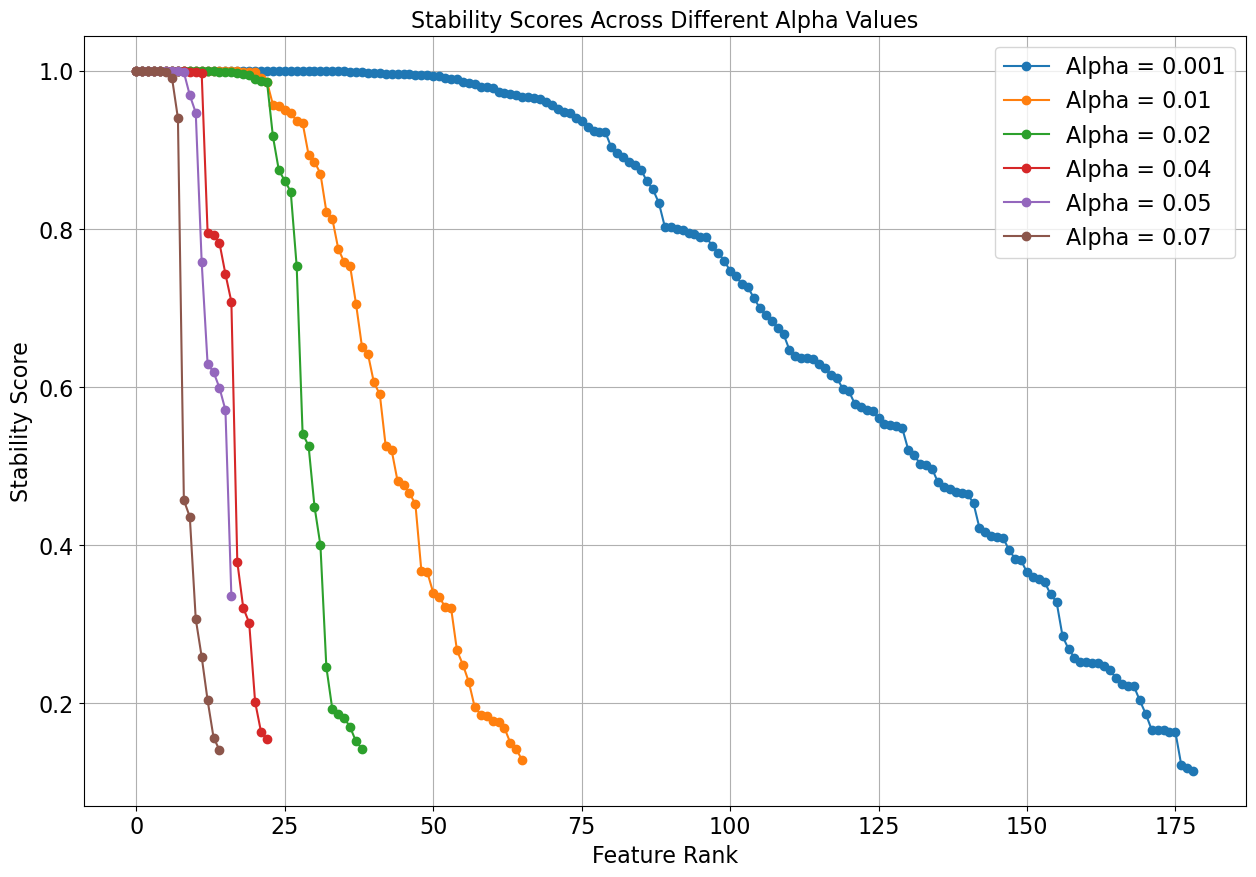

In [61]:
# Plot stability scores for each alpha
plt.figure(figsize=(15, 10))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=16)
plt.ylabel('Stability Score',fontsize=16)
plt.xticks(fontsize=16)  # Make x-axis tick labels larger
plt.yticks(fontsize=16)  # Make y-axis tick labels larger
plt.legend(fontsize=16)
plt.grid(True)
plt.show()

In [11]:
### Check the penalized parameter (alpha) that was stored as a dictionary 

In [63]:
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

In [13]:
# feature_importance_df_07=results[0.01][results[0.01].Stability_Score>0.7]
feature_importance_df=results[0.01]
feature_importance_df

,Feature,Stability_Score
117,ABDOMEN_min,1.0
104,FLOW_p25,1.0
217,HR_max,1.0
198,ACC_Y_min,1.0
219,HR_std,1.0
...,...,...
102,FLOW_std,0.0
103,FLOW_p5,0.0
105,FLOW_p50,0.0
106,FLOW_p75,0.0


### If we want to see features with a spefic threshold

In [15]:
results[0.02][results[0.02].Stability_Score>0.6]

,Feature,Stability_Score
117,ABDOMEN_min,1.000
219,HR_std,1.000
81,ECG_min,1.000
168,BVP_p50,1.000
87,ECG_p50,1.000
162,BVP_min,1.000
95,PTAF_p25,1.000
192,ACC_X_std,1.000
97,PTAF_p75,1.000
100,FLOW_max,1.000


In [16]:
len(results[0.02][results[0.02].Stability_Score>0.2])

35

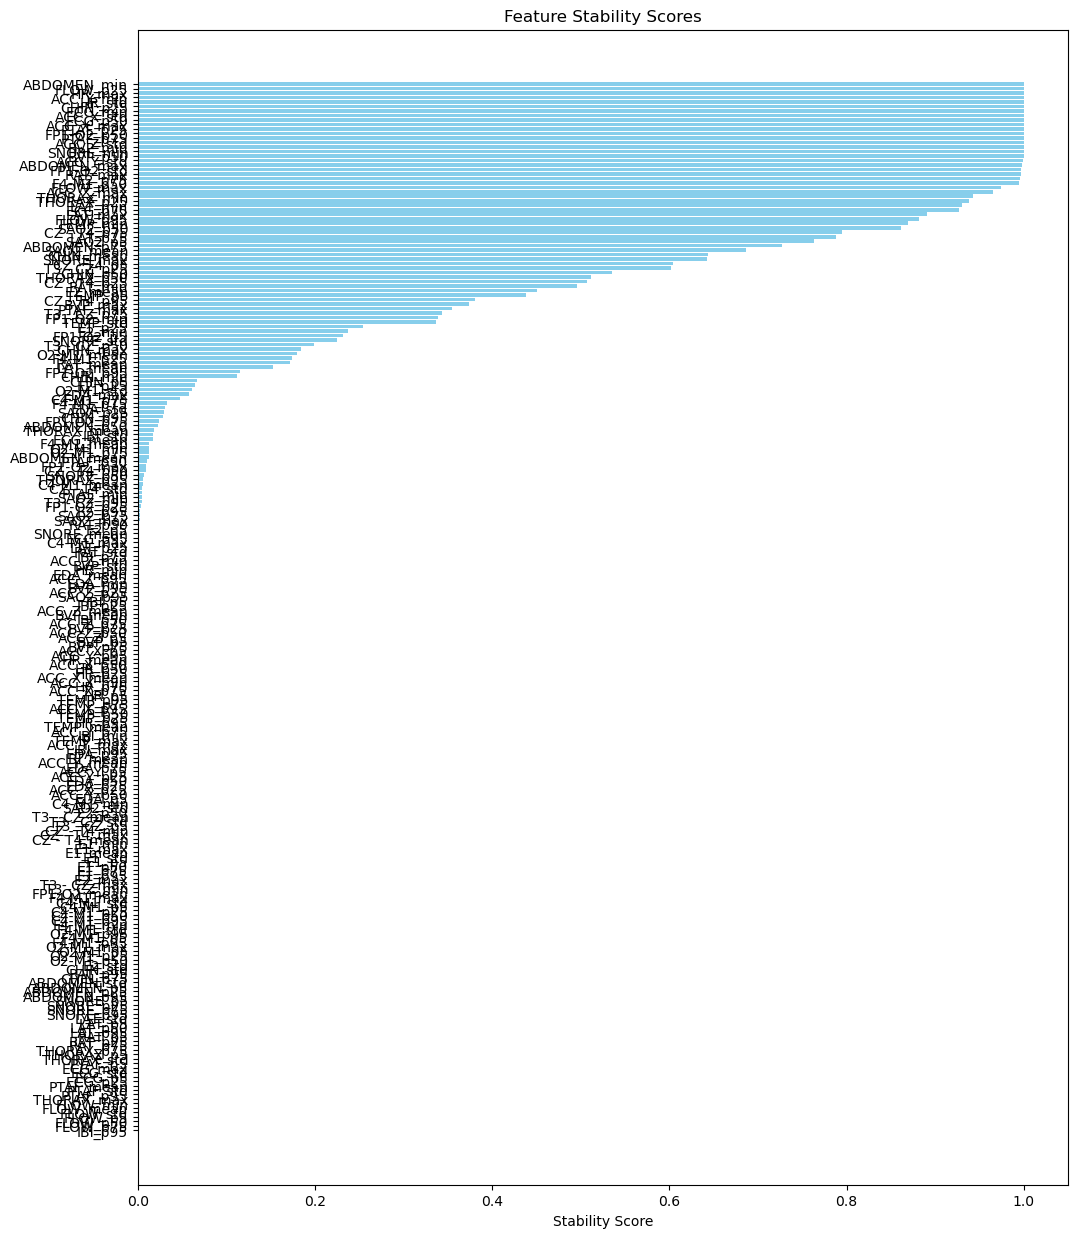

In [17]:
# Plotting the features vs. stability scores
feature_importance_df=results[0.01]
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
plt.show()

In [18]:
# # Plotting the features vs. stability scores
# feature_importance_df=results[0.02]
# plt.figure(figsize=(12, 15))
# plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
# plt.xlabel('Stability Score')
# plt.title('Feature Stability Scores')
# plt.gca().invert_yaxis()
# plt.show()

In [19]:
# # Plotting the features vs. stability scores
# feature_importance_df=results[0.05]
# plt.figure(figsize=(12, 15))
# plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
# plt.xlabel('Stability Score')
# plt.title('Feature Stability Scores')
# plt.gca().invert_yaxis()
# plt.show()

In [20]:
feature_importance_df_07=results[0.02][results[0.02].Stability_Score>=0.7]['Feature'].values
feature_importance_df_07
sel_col=np.append(feature_importance_df_07,'label')
sel_col

array(['ABDOMEN_min', 'HR_std', 'ECG_min', 'BVP_p50', 'ECG_p50',
       'BVP_min', 'PTAF_p25', 'ACC_X_std', 'PTAF_p75', 'FLOW_max',
       'FP1-O2_p50', 'FP1-O2_std', 'ACC_Z_std', 'HR_max', 'ACC_Y_std',
       'CHIN_p25', 'RAT_max', 'ACC_Y_min', 'SAO2_mean', 'SNORE_min',
       'ABDOMEN_max', 'FLOW_p25', 'TEMP_min', 'ACC_X_max', 'LAT_min',
       'LAT_max', 'E2_p75', 'F4-M1_p50', 'label'], dtype=object)

## selecting the features that  have stability scores more that 0.7

In [22]:
df_sample.columns

Index(['subject', 'epoch', 'label', 'C4-M1_min', 'C4-M1_max', 'C4-M1_mean',
       'C4-M1_std', 'C4-M1_p5', 'C4-M1_p25', 'C4-M1_p50',
       ...
       'HR_p95', 'IBI_min', 'IBI_max', 'IBI_mean', 'IBI_std', 'IBI_p5',
       'IBI_p25', 'IBI_p50', 'IBI_p75', 'IBI_p95'],
      dtype='object', length=237)

In [23]:
df1=df_sample[sel_col]
df1

,ABDOMEN_min,HR_std,ECG_min,BVP_p50,ECG_p50,BVP_min,PTAF_p25,ACC_X_std,PTAF_p75,FLOW_max,...,SNORE_min,ABDOMEN_max,FLOW_p25,TEMP_min,ACC_X_max,LAT_min,LAT_max,E2_p75,F4-M1_p50,label
305,-0.000471,2.143001,-0.000207,4.025,-0.000007,-1257.38,-0.001435,3.628029,-0.000341,0.000063,...,-0.000060,0.000736,-0.000013,32.07,-5.0,-0.000070,0.000067,0.000006,5.371176e-07,0.0
306,-0.000599,1.018599,-0.000223,1.430,-0.000005,-749.06,-0.001557,1.299924,-0.000843,0.000072,...,-0.000007,0.001070,-0.000028,32.07,-15.0,-0.000010,0.000010,0.000005,1.464866e-07,0.0
307,-0.000575,0.448284,-0.000250,2.820,-0.000005,-281.51,-0.001517,0.837405,-0.000877,0.000066,...,-0.000021,0.000878,-0.000018,32.09,-15.0,-0.000011,0.000010,0.000006,-4.882887e-08,0.0
308,-0.000454,1.220139,-0.000198,6.530,-0.000006,-369.24,-0.001292,0.998854,-0.000649,0.000057,...,-0.000007,0.000935,-0.000019,32.18,-15.0,-0.000024,0.000029,0.000005,-4.882887e-08,0.0
309,-0.000692,1.942701,-0.001434,1.215,-0.000005,-572.48,-0.001336,2.930675,-0.000585,0.000091,...,-0.000036,0.000929,-0.000028,32.25,-7.0,-0.000073,0.000045,0.000006,5.371176e-07,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,-0.000346,0.989816,-0.000938,10.170,0.000033,-367.93,-0.000089,0.269701,0.000026,0.000433,...,-0.000057,0.000345,-0.000120,35.37,-34.0,-0.000031,0.000060,0.000004,4.882887e-08,1.0
95143,-0.000639,0.198988,-0.000972,12.155,0.000033,-294.16,-0.000196,0.488773,0.000049,0.000614,...,-0.000042,0.000528,-0.000134,35.37,-33.0,-0.000049,0.000116,0.000005,-1.464866e-07,1.0
95144,-0.000259,0.220233,-0.000965,11.370,0.000032,-369.02,-0.000120,0.557287,0.000039,0.000320,...,-0.000028,0.000334,-0.000165,35.37,-31.0,-0.000024,0.000020,0.000004,2.441444e-07,1.0
95145,-0.000310,0.387480,-0.000958,8.610,0.000033,-663.33,-0.000097,0.454679,0.000021,0.000299,...,-0.000030,0.000230,-0.000151,35.37,-34.0,-0.000017,0.000009,0.000004,2.441444e-07,1.0
